# MPCs in a Simple Incomplete Markets Model

This notebook contains some applications related to marginal propensities to consume in the standard incomplete markets model, that was introduced in detail in an earlier notebook. 

We will use the module `incomplete_markets.jl` that contains some functions to solve for the equilibrium:

In [11]:
include("incomplete_markets.jl");

Before getting into MPCs lets solve for the steady state of the model

In [12]:
a, c, a₊, D, C, A = solveIncompleteMarkets(0., 200., 500, Params());

## MPCs

The derivative of this consumption function - divided by $1+r$ to adjust for the fact that assets are prereturn - tells us the marginal propensity to consume out of an additional dollar of assets. 

Concavity of the consumption functions above tells us that this derivative is declining - so the more assets you have, the smaller your MPC. The idea is that as your assets increase you behave more and more like a permanent income consumer - where your marginal propensity to consume out of additional wealth is simply $r$ - the interest rate of the economy.

Let's calculate the MPCs using some simple numerical differentiation - which is maybe not the most precise but then again we have discontinuous MPCs.

The interest rate used to solve the baseline model is $ r = \frac{0.01}{4} $

In [33]:
function MPC(a, c, a₊, r)
    mpc = similar(c)
    
    # symmetric differences away from boundaries
    mpc[2:end-1, :] = (c[3:end, :] .- c[1:end-2, :]) ./ (a[3:end] - a[1:end-2]) / (1+r)
    
    # asymmetric first differences at boundaries
    mpc[1, :] = (c[2, :] - c[1, :]) / (a[2] - a[1]) / (1+r)
    mpc[end, :] = (c[end, :] - c[end-1, :]) / (a[end] - a[end-1]) / (1+r)
    
    return mpc
end
    

MPC (generic function with 1 method)

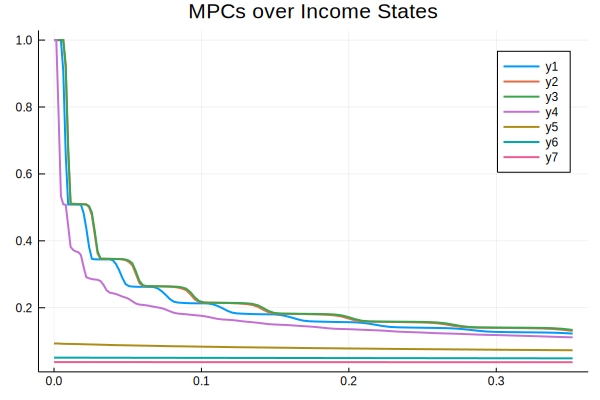

In [34]:
r = 0.01/4
mpc = MPC(a, c, a₊, r);
plot(a[1:100], mpc[1:100,:], lw = 2, title = "MPCs over Income States")

The discontinuities don't seem to be accidental. Given the discretized process for income there are discrete jumps in the MPCs in the near horizon because you will hit the constraint in a given number of periods provided you remain in that income state.

For instance, if we stay in the low income state and your level of assets is to the right of zero, then the jumps correspond to the fact that you have the level of assets that corresponds to being constrained in $n$ periods conditional on remaining in the same state. 

To be more concrete, if you are to the right of the first jump but to the left of the second one. This means that you currently have the level of assets such that if you stay in that state you will hit the constraint in one period and so on.

## Aside: Lorenz curve

We can also try plotting the Lorenz curve - the cumulative percentile of total assets against the cumulative percentile of the population - a common measure of total inequality for assets or income

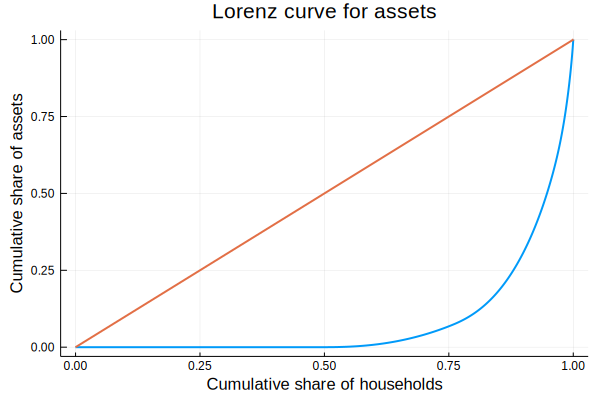

In [51]:
pop = cumsum(sum(D, dims=2), dims = 1)
assets = cumsum(sum(D, dims =2) .* a, dims = 1)/A

# Add zeros so that everything starts at 0
pop = vcat(0, pop)
assets = vcat(0, assets)

plot(pop, assets, lw = 2, legend = false, title = "Lorenz curve for assets")
plot!(pop, pop, lw = 2, xlabel = "Cumulative share of households", 
      ylabel = "Cumulative share of assets")

Visually we can see that there are strong forces for inequality in the model. The gap between the 45-degree line and the blue curve is significant. This says that the top 10\% account hold around 70\% of total assets in this economy.

## Impatience and MPCs

We now turn to some experiments looking at what happens to assets and MPCs in this economy as we vary the preference parameter $\beta$ which captures how impatient consumers are in this economy.

We will compute unweighted, asset-weighted and income-weighted MPCs as we change $\beta$ as well

In [55]:
y, pr, Π = IncomeProcess(Params()) # we will need the income process

beta_star = Params().β # save for later
1/(1+r) #bound to see how high we can go

0.9975062344139651

In [96]:
betas = collect(range(0.96, 0.996, length = 30));
As = similar(betas)
mpcs = similar(betas)
mpcs_income = similar(betas)
mpcs_assets = similar(betas)

for (i, beta) in enumerate(betas)
    a, c, a₊, D, C, A = solveIncompleteMarkets(0., 200.,500,Params(β = beta))
    As[i] = A
    mpc = MPC(a, c, a₊, r)
    mpcs[i] = mpc ⋅ D
    mpcs_income[i] = mpc ⋅ (D .* y')
    mpcs_assets[i] = mpc ⋅ (D .* a) / A
end    

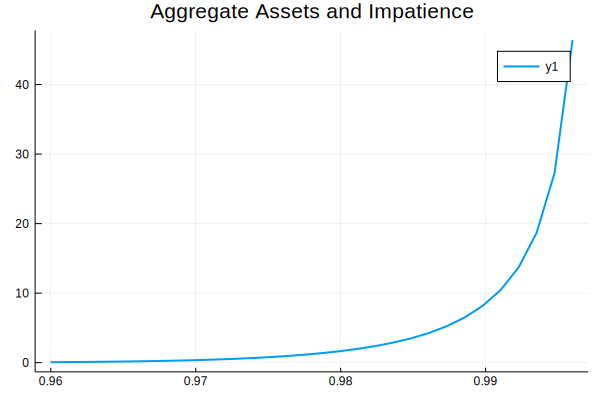

In [97]:
plot(betas, As, lw = 2, title = "Aggregate Assets and Impatience")

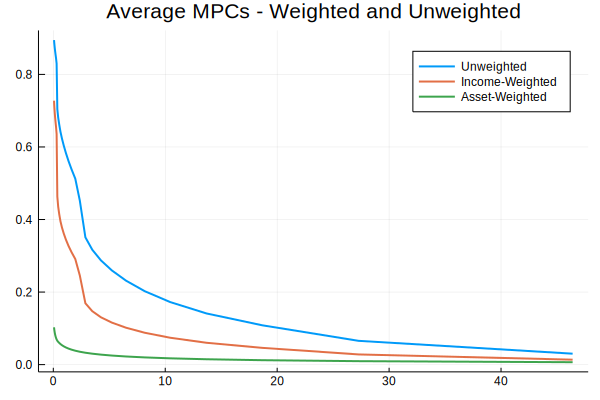

In [113]:
plot(As, [mpcs,mpcs_income, mpcs_assets], lw = 2, title = "Average MPCs - Weighted and Unweighted",
     label = ["Unweighted" "Income-Weighted" "Asset-Weighted"])

Remarks related to the findings above:
1. Aggregate assets asymptote to infinity as $\beta(1+r)$ approaches one from below. We saw this result last year - essentially you approach the representative agent case - we know that $\beta(1+r) = 1$ for steady state to be well defined in the case of complete markets. With incomplete markets there is an additional force pushing you to accumulate assets - precautionary motive - so you diverge.

2. Average MPCs start high but go to the representative agent level as we increase $\beta$ or the aggregate level of assets in equilibrium. Note that we are plotting against aggregate assets. If we want to interpret - let's say that assets are ten times labor income at the annual level which is somewhat in the ballpark of what we actually see. Assets are a stock so they are 40 times labor income when we are at a quarterly frequency. So that means that this calibration would imply an average MPC for our eocnomy very close to 0. This is well below the 0.2 that seems to be consistent with most studies.

3. Income-weighted MPCs are a lot lower. This comes from the negative correlation we saw in the first figure regarding MPCs and income states - the lower your income the higher your MPC. So when you take income weighted MPCs you are putting less weight on the high MPC people. It seems to be the case that MPCS aren't that much lower for higher income people, according to Auclert and Rognlie (2020). 

4. Asset-weighted MPCs are even lower - but this is no surprise because the only reason people have higher MPCs is because they are close to constraint and/or because of labor income uncertainty, both of which become less relecant as they accumulate assets. This still contradicts some evidence that there are some **wealthy hand-to-moouth** consumers - the idea is that a lot of wealth is illiquid and so people with a lot of (illiquid) wealth can still have high MPCs - also some issues though: what really is illiquid?


In general this points to a frequent problem you run into when calibrating this class of models, you want to choose $\beta$ in order to hit a reasonable amount of assets. However, when doing so you go to a very low average MPC, getting very little out of the heterogeneity of the model.

To match both high total assets and high aggregate MPCs you can use some kind of trick - like discount factor heterogeneity so that effectively you form a convex combination of two points in the graph above so you are at a more reasonable point in the space. But this solution is often unsatisfactory as it can reduce the model to a simple two-agent spender-saver model - one agent is on their Euler equation and the other one simply has an MPC of one.